# Peer-to-peer Loan Data Analysis 💰 - III

### 📊 Exploratory Data Analysis & Visualisations using `Seaborn` & `Matplotlib`

Seaborn offers many cool plot types beyond column and distributional charts, like heatmaps, violin plots, regression plots, and more

## Scenario - 1: 
### `Heatmap`

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

In [3]:
df = pd.read_csv("loan_data.csv")

In [4]:
df.head()

,emp_title,emp_length,state,homeownership,debt_to_income,annual_income,open_credit_lines,total_credit_limit,total_credit_utilized,total_debit_limit,loan_amount,interest_rate,installment,grade,balance,paid_interest
0,administrative assistant,0,FL,RENT,22.51,32000.0,4,22984,18420,5000,2500,7.96,78.30,A,2326.16,31.65
1,sole proprietor,10,MN,OWN,2.99,45000.0,5,203255,1469,9000,12500,7.34,387.91,A,11559.92,218.55
2,pension ananlyst,10,MD,OWN,21.07,90000.0,19,154848,62112,79300,13000,7.35,403.49,A,11360.72,364.90
3,director of corporate operations,0,MN,MORTGAGE,12.28,130000.0,23,296496,77944,93600,17500,7.35,349.42,A,16273.90,470.99
4,dispatcher,3,TX,RENT,28.97,65000.0,28,156207,70381,50800,8000,7.96,250.55,A,7403.61,151.72


* Let's start with the code to create a **correlation matrix.**

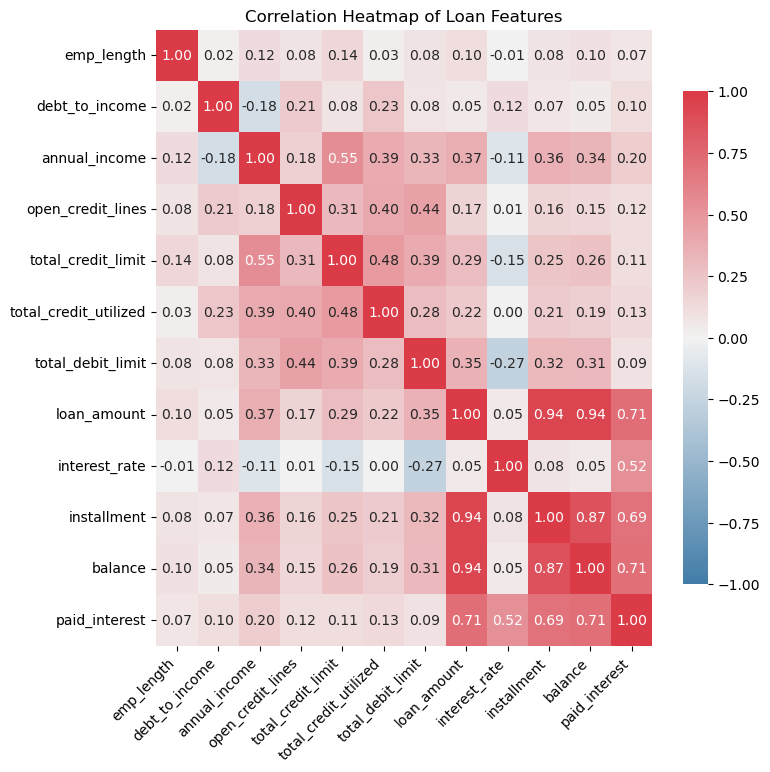

In [16]:
# Selecting the relevant columns for correlation
corr_features = ["emp_length", "debt_to_income", "annual_income", "open_credit_lines", 
                 "total_credit_limit", "total_credit_utilized", "total_debit_limit", 
                 "loan_amount", "interest_rate", "installment", "balance", "paid_interest"
]

# Compute the correlation matrix
corr_table = df[corr_features].corr()        

# Create a custom colormap
custom_cmap = sns.diverging_palette(240, 10, as_cmap=True)   #240 is blue, 10 is red

# Create a heatmap with the custom colormap
plt.figure(figsize=(8,8))

sns.heatmap(corr_table,
            annot=True,
            fmt="0.2f",
            cmap=custom_cmap,
            center=0,    # this ensures white is at 0
            vmin=-1,     # force the scale from -1 to 1
            vmax=1,
            cbar_kws={"shrink": 0.8})

plt.title("Correlation Heatmap of Loan Features")
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.savefig("corr_heatmap.png")

* If we just look at correlation table on its own below, we have a table of a ton of numbers and it's hard to see what matters. 

* But in the heatmap, we can see **negative correlations** are shown in **increasingly darker blues**, with **interest rate** and **total debt limit** having the **strongest negative correlation.**

* Then, **positive correlations** are in **red**, with many positive relationships. 

* We could share this visualization with our stakeholders to, for example, help them understand different opportunities to predict paid interest to identify the most profitable loans. Or we could use it ourself to select a few scatter plots to create. 

In [6]:
corr_table

,emp_length,debt_to_income,annual_income,open_credit_lines,total_credit_limit,total_credit_utilized,total_debit_limit,loan_amount,interest_rate,installment,balance,paid_interest
emp_length,1.000000,0.017722,0.117680,0.079097,0.141088,0.029949,0.083761,0.103392,-0.006981,0.081590,0.097132,0.065057
debt_to_income,0.017722,1.000000,-0.177448,0.213761,0.080848,0.234977,0.075303,0.050399,0.118798,0.065365,0.045418,0.104210
annual_income,0.117680,-0.177448,1.000000,0.180854,0.546688,0.386707,0.327736,0.369342,-0.110327,0.356356,0.335160,0.202625
open_credit_lines,0.079097,0.213761,0.180854,1.000000,0.305617,0.401110,0.440965,0.166330,0.006714,0.157172,0.145561,0.116069
total_credit_limit,0.141088,0.080848,0.546688,0.305617,1.000000,0.483828,0.387536,0.288242,-0.148337,0.245758,0.260492,0.109863
total_credit_utilized,0.029949,0.234977,0.386707,0.401110,0.483828,1.000000,0.284368,0.218837,0.003542,0.213650,0.192534,0.133500
total_debit_limit,0.083761,0.075303,0.327736,0.440965,0.387536,0.284368,1.000000,0.349074,-0.265748,0.319035,0.309142,0.093378
loan_amount,0.103392,0.050399,0.369342,0.166330,0.288242,0.218837,0.349074,1.000000,0.047447,0.941512,0.938655,0.713509
interest_rate,-0.006981,0.118798,-0.110327,0.006714,-0.148337,0.003542,-0.265748,0.047447,1.000000,0.084006,0.047367,0.524692
installment,0.081590,0.065365,0.356356,0.157172,0.245758,0.213650,0.319035,0.941512,0.084006,1.000000,0.867745,0.690433


## Scenario - 2: 
### `Violin Plot`

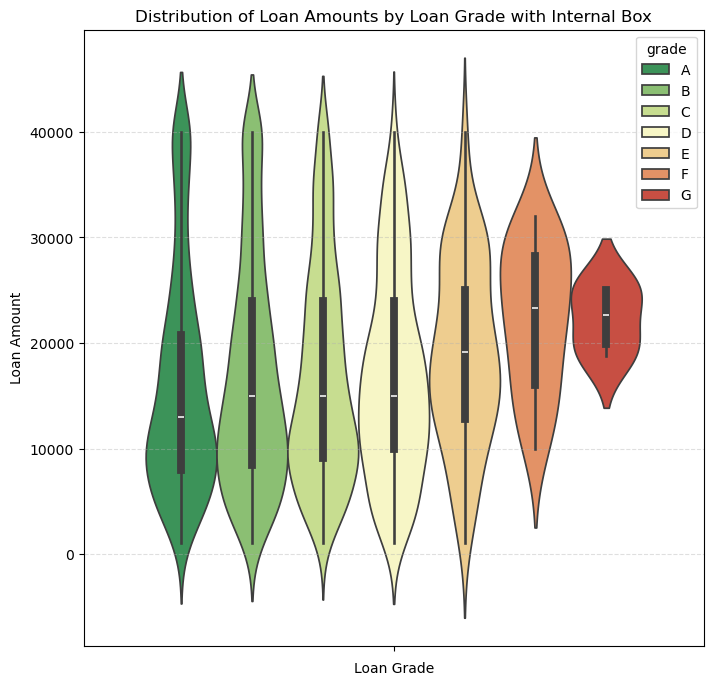

In [18]:
# Creating a violin plot with builtin "box" for internal statistics
plt.figure(figsize=(8,8))
sns.violinplot(df, hue="grade", y="loan_amount", inner="box", palette="RdYlGn_r")

# Add a grid on the y-axis
plt.grid(axis="y", alpha=0.4, linestyle="--")

plt.title("Distribution of Loan Amounts by Loan Grade with Internal Box")
plt.xlabel("Loan Grade")
plt.ylabel("Loan Amount")
plt.savefig("loan_amounts_by_grade_violinplot.png")

A **violin plot is similar to a box plot** in the sense that it visualizes the **distribution of the data**, but it also provides additional insight about where the **mass of data** is located. 

**Inside each violin plot** is a **box plot of loan amount.**

* So, for example, we can see that loan grades `A` through `D` have a similar median amount, but that the mass of the data moves upwards as the grade gets worse. 

* `A` loans have a median around 12,500 or so, and they're very skewed up, aka positively skewed. `D` loans are less skewed, with a median loan amount around 15,000, while `E` loans are more symmetric, and `F` loans are actually skewed down, aka skewed negatively. 

* Ultimately, the measures of central tendency, variability, and skewness of the loan amounts vary across the different grade categories.

## Scenario-3:
### `Regression plot`

The code creates a regression plot to visualize the relationship between paid interest and loan amount. 

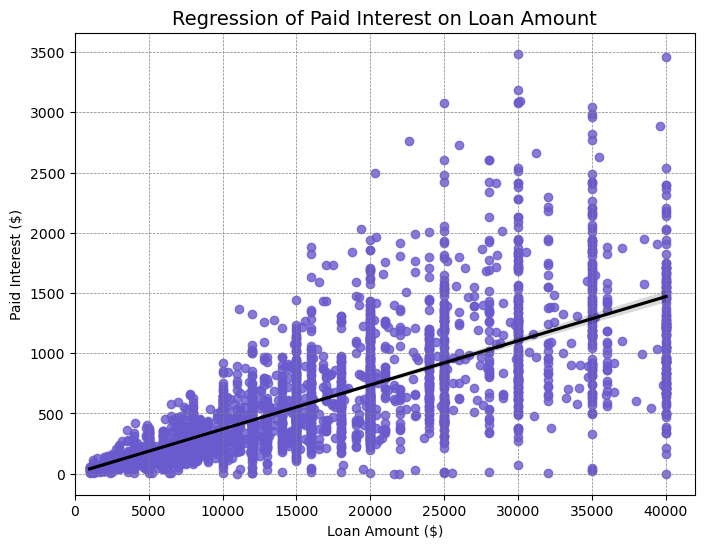

In [20]:
# Creating a regression plot for paid interest versus loan amount
plt.figure(figsize=(8,6))
sns.regplot(df, x="loan_amount", y="paid_interest", 
            scatter_kws={"color":"slateblue"},
            line_kws={"color":"black"})

plt.title("Regression of Paid Interest on Loan Amount", fontsize=14)
plt.xlabel("Loan Amount ($)")
plt.ylabel("Paid Interest ($)")
plt.grid(linestyle="--", linewidth="0.5", color="gray")

# Setting the axes to start at 0
plt.xlim(left=0)

plt.savefig("paid_interest_on_loan_amount_regplot.png")

We get a scatter plot with an overlaid **line of best fit.** The line is generated automatically by this plot type, a reg plot. 

* This is a pretty strong relationship, which makes sense because in the heat map, we saw that loan amount and paid interest had a correlation coefficient of 0.71, which is on the stronger side.

* We can also see the clusters around the different loan amounts, like 35,000 and 40,000.

* This type of plot might help our stakeholders understand the relationship between paid interest and the loan amount.

* We notice that the loan amount only explains about 71% of the variability in paid interest. So we can see on this line for 25,000 loans, for example, we have loans that have no interest paid. Maybe that's a brand new loan with a lot of values clustering around 1,000. So other features like the interest rate or the length of the loan will be needed to estimate the profitability of different loans more accurately.